In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
df = pd.read_csv('/content/linkedin_jobs_with_extracted_skills_per_job (2).csv')

print(f"Dataset loaded: {len(df)} jobs")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample job titles:")
print(df['title'].value_counts().head(20))



Dataset loaded: 1075 jobs
Columns: ['title', 'company', 'location', 'date', 'job_link', 'description', 'search_keyword', 'relevant_section', 'title_cleaned', 'cluster_id', 'auto_category', 'final_category', 'extracted_skills_list', 'extracted_skills', 'num_skills']

Sample job titles:
title
Data Scientist/ML Engineer                      12
Senior Data Scientist                           11
Senior Software Engineer                        10
Junior AI Engineer                               8
Senior Software QA Engineer                      7
Development Intern                               7
Graphic Designer                                 6
AI Engineer                                      6
Software Engineer                                6
AI Engineer [F/M/X]                              6
English Speaker Lead Generation Specialist       5
Project Engineer Intern                          5
Senior Software ADAS Engineer                    5
Data engineer                                

In [ ]:
def extract_relevant_section(text):
    """
    Extract only the relevant parts: missions, responsibilities, qualifications
    Skip company description
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Keywords that mark START of relevant content (French & English)
    start_keywords = [
        # French
        r'vos challenges',
        r'votre mission',
        r'description du poste',
        r'missions principales',
        r'vos missions',
        r'responsabilités',
        r'about the role',
        r'what you.?ll do',
        r'responsibilities',
        r'job description',
        r'your missions',
        r'key responsibilities',
        r'missions',
        r'poste',
        # English
        r'role overview',
        r'position summary',
        r'what you will do',
        r'duties',
    ]

    # Find the earliest match
    text_lower = text.lower()
    start_idx = len(text)  # Default to end if not found

    for keyword in start_keywords:
        match = re.search(keyword, text_lower)
        if match:
            start_idx = min(start_idx, match.start())

    # If no relevant section found, use full text (but this is rare)
    if start_idx == len(text):
        return text

    return text[start_idx:]


# Apply extraction
print("Extracting relevant sections from descriptions...")
df['relevant_section'] = df['description'].apply(extract_relevant_section)

# Compare before/after
print("\n" + "="*60)
print("EXAMPLE: Before extraction")
print("="*60)
print(df['description'].iloc[1][:400])

print("\n" + "="*60)
print("EXAMPLE: After extraction (relevant section only)")
print("="*60)
print(df['relevant_section'].iloc[1][:400])

print(f"\nAverage length before: {df['description'].str.len().mean():.0f} chars")
print(f"Average length after: {df['relevant_section'].str.len().mean():.0f} chars")


Extracting relevant sections from descriptions...

EXAMPLE: Before extraction
With its beginnings in a family run pharmacy in Correggio, Italy in the 1920s, Recordati is now a global pharmaceutical company, listed on the Italian stock exchange, with over 4,500 employees and turnover of over Euro 2bn.
We are a group of like-minded, passionate individuals who go to extraordinary lengths for our patients, customers, partners, investors and the people across the globe who we se

EXAMPLE: After extraction (relevant section only)
Responsabilités et activités principales
Gestion et structuration des données magasins
Collecter, nettoyer et structurer les données issues de l’ERP (SAP, Oracle, Dynamics…).
Mettre en place des modèles de données pour la gestion des stocks.
Assurer la cohérence des données articles, lots, dates de péremption et emplacements.
Gérer les référentiels (articles, fournisseurs, emplacements, unités).
T

Average length before: 2625 chars
Average length after: 2181 chars


In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download required NLTK data (run once)
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except:
    pass

def preprocess_text(text):
    """Clean text for analysis"""
    if pd.isna(text) or text == "":
        return ""

    text = str(text).lower()

    # Remove URLs and emails
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # Remove punctuation but keep spaces
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove digits
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def remove_stopwords_bilingual(text):
    """Remove English and French stopwords"""
    if not text:
        return ""

    # Get stopwords for both languages
    stop_words = set()
    try:
        stop_words.update(stopwords.words('english'))
        stop_words.update(stopwords.words('french'))
    except:
        pass

    # Add custom stopwords (job-related generic terms)
    custom_stops = {
        'experience', 'expérience', 'ans', 'years', 'année', 'annees',
        'poste', 'job', 'work', 'travail', 'company', 'entreprise',
        'candidat', 'candidate', 'profil', 'profile', 'recherche',
        'looking', 'team', 'équipe', 'equipe', 'opportunity', 'opportunité',
        'role', 'position'
    }
    stop_words.update(custom_stops)

    words = text.split()
    filtered = [w for w in words if w not in stop_words and len(w) > 2]

    return " ".join(filtered)

In [ ]:
df['job_category'] = df['title'].apply(normalize_job_title)

# Show distribution
print("Job categories distribution:")
print(df['job_category'].value_counts())

# Visualize
plt.figure(figsize=(12, 6))
df['job_category'].value_counts().head(15).plot(kind='barh')
plt.xlabel('Number of Jobs')
plt.title('Top Job Categories in Dataset')
plt.tight_layout()
plt.savefig('job_categories_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(f"Total jobs: {len(df)}")
print(f"Unique job titles: {df['title'].nunique()}")


# ============================================================
# STEP 1: Clean and normalize job titles
# ============================================================

def clean_title(title):
    """Basic cleaning without categorization"""
    if pd.isna(title):
        return ""

    title = str(title).lower()

    # Remove common noise
    noise_terms = [
        r'\(h/f\)', r'\(f/m/x\)', r'\(m/f/x\)', r'\(w/m\)',
        r'\[f/m/x\]', r'h/f', r'f/h', r'm/f', r'w/m',
        r'- tunis', r'tunis -', r'remote', r'relocat.*',
        r'located geographically.*', r'\(.*portugal.*\)',
        r'\(.*dubai.*\)', r'internship', r'stagiaire'
    ]

    import re
    for pattern in noise_terms:
        title = re.sub(pattern, '', title, flags=re.IGNORECASE)

    # Remove extra spaces
    title = re.sub(r'\s+', ' ', title).strip()

    return title

df['title_cleaned'] = df['title'].apply(clean_title)

print(f"\nCleaned titles - sample:")
print(df[['title', 'title_cleaned']].head(10))



Total jobs: 1075
Unique job titles: 596

Cleaned titles - sample:
                                               title  \
0                                 BI / Data Engineer   
1                                      Data engineer   
2                                      Data Engineer   
3                              Data Engineer [F/M/X]   
4                                       Data Analyst   
5                                 Junior AI Engineer   
6                                  Software Engineer   
7  Embedded System Engineer (m/f/x) in Sfax, Tunisia   
8                         Data Scientist/ML Engineer   
9                                AI Engineer [F/M/X]   

                               title_cleaned  
0                         bi / data engineer  
1                              data engineer  
2                              data engineer  
3                              data engineer  
4                               data analyst  
5                         junior ai

In [ ]:
unique_titles = df['title_cleaned'].unique()
unique_titles = [t for t in unique_titles if len(t) > 2]  # Remove very short titles

print(f"\n{len(unique_titles)} unique cleaned titles")

# Create TF-IDF vectors
vectorizer = TfidfVectorizer(
    analyzer='char_wb',  # Character n-grams to handle typos
    ngram_range=(2, 4),  # 2-4 character sequences
    min_df=1,
    max_df=0.8
)

title_vectors = vectorizer.fit_transform(unique_titles)

print(f"TF-IDF matrix shape: {title_vectors.shape}")


580 unique cleaned titles
TF-IDF matrix shape: (580, 6354)


In [ ]:
# Compute similarity matrix
similarity_matrix = cosine_similarity(title_vectors)

# Convert similarity to distance
distance_matrix = 1 - similarity_matrix

# Cluster using Agglomerative Clustering
# n_clusters: adjust based on how many categories you want
# Higher = more specific categories, Lower = broader categories

n_clusters = 30  # Start with 30, adjust as needed

clustering = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='precomputed',
    linkage='average'
)

cluster_labels = clustering.fit_predict(distance_matrix)

# Create mapping from title to cluster
title_to_cluster = dict(zip(unique_titles, cluster_labels))

print(f"\nClustered {len(unique_titles)} titles into {n_clusters} groups")



Clustered 580 titles into 30 groups


In [ ]:
from collections import Counter
import re

def extract_keywords(titles):
    """Extract most common keywords from a list of titles"""
    all_words = []

    for title in titles:
        # Remove common words
        stop_words = ['senior', 'junior', 'lead', 'principal', 'confirmé',
                     'confirmed', 'intern', 'stagiaire', 'stage']
        words = title.split()
        words = [w for w in words if w not in stop_words and len(w) > 2]
        all_words.extend(words)

    # Get most common
    word_counts = Counter(all_words)

    if not word_counts:
        return "Uncategorized"

    # Take top 2 most common words
    top_words = [word for word, count in word_counts.most_common(2)]
    return " ".join(top_words).title()


In [ ]:
# Group titles by cluster and name each cluster
cluster_names = {}
cluster_titles = {}

for cluster_id in range(n_clusters):
    # Get all titles in this cluster
    titles_in_cluster = [title for title, cid in title_to_cluster.items() if cid == cluster_id]
    cluster_titles[cluster_id] = titles_in_cluster

    # Generate name
    cluster_name = extract_keywords(titles_in_cluster)
    cluster_names[cluster_id] = cluster_name

print(f"\n{'='*70}")
print("AUTOMATICALLY GENERATED CATEGORIES")
print(f"{'='*70}")

for cluster_id in sorted(cluster_names.keys()):
    titles = cluster_titles[cluster_id]
    print(f"\n{cluster_names[cluster_id]} ({len(titles)} titles):")
    print("  Sample titles:", ", ".join(titles[:5]))



AUTOMATICALLY GENERATED CATEGORIES

Engineer Software (71 titles):
  Sample titles: bi / data engineer, data engineer, junior ai engineer, software engineer, embedded system engineer in sfax, tunisia

Buyer Project (8 titles):
  Sample titles: procurement buyer (tunis lac 3- position based), project buyer, it project management officer, project officer (data & research) (p), sales back office

Ingénieur Technicien (71 titles):
  Sample titles: technical support engineer - l2, un ingénieur cloud aws, ingénieur devops, ingénieur systèmes & cloud senior, ingénieur devops confirmé

Manager Management (50 titles):
  Sample titles: product manager - saas btob (junior/intermediate), delivery manager - cloud & devops, release manager, ingénieur identity and access management, country général manager

Developer Développeur (109 titles):
  Sample titles: lead cloud platform engineer, full-stack engineer (web & apis), senior frontend engineer (complex data & dashboards), lead full-stack engineer

In [ ]:
# Map each job to its cluster
df['cluster_id'] = df['title_cleaned'].map(title_to_cluster)
df['auto_category'] = df['cluster_id'].map(cluster_names)

# Handle any unmapped titles
df['auto_category'] = df['auto_category'].fillna('Other')

# Show distribution
print(f"\n{'='*70}")
print("CATEGORY DISTRIBUTION")
print(f"{'='*70}")
category_dist = df['auto_category'].value_counts()
print(category_dist)

print(f"\n'Other' category: {category_dist.get('Other', 0)} jobs ({category_dist.get('Other', 0)/len(df)*100:.1f}%)")



CATEGORY DISTRIBUTION
auto_category
Engineer Software            195
Developer Développeur        166
Ingénieur Technicien         120
Manager Management            91
Consultant Sap                74
Specialist Product            69
Data Scientist                44
Analyst Business              44
Chef Projet                   39
Commercial Chargé(E)          36
Designer Graphic              34
Responsable Safran            29
Administrator Network         26
Tech Java                     16
Marketing Video               16
Opportunity Build             15
Buyer Project                 15
Opérateur Télévendeur(Se)      9
Recruiter (Freelance           8
Expert Web                     5
Other                          3
Associate Rims                 3
Maximo Developer               3
Growth Hacker                  3
Executive Assistant            2
Placier (Zones                 2
Mental Health                  2
Fondateur Startup              2
Conducteur Machine             2
Pharma

In [ ]:
category_refinement = {
    # ── Software Engineering ──
    'Engineer Software':            'Software Engineering',
    'Developer Full':               'Software Engineering',

    # ── DevOps & Cloud ──
    'Ingénieur Devops':             'DevOps & Cloud',

    # ── Data Science & ML ──
    'Data Scientist':               'Data Science & ML',

    # ── BI & Data Analysis ──
    'Analyst Business':             'BI & Data Analysis',

    # ── IT Consulting & ERP ──
    'Consultant Sap':               'IT Consulting & ERP',

    # ── IT Support & Technician (merge Ingénieur Technicien here) ──
    'Support Specialist':           'IT Support & Technician',
    'Administrator Administrateur': 'IT Support & Technician',
    'Functional Function':          'IT Support & Technician',
    'Ingénieur Technicien':         'IT Support & Technician',  # ← ADD

    # ── Project Management ──
    'Chef Projet':                  'Project Management',
    'Officer Directeur':            'Project Management',
    'Team Tech':                    'Project Management',

    # ── Design & Graphics ──
    'Designer Graphic':             'Design & Graphics',

    # ── Business & Operations (absorb tiny categories) ──
    'Communication Application':    'Business & Operations',
    'Assistant Executive':          'Business & Operations',
    'Buyer Procurement':            'Business & Operations',
    'Associate Rims':               'Business & Operations',
    'Recruiter (Freelance':         'Business & Operations',
    'Video Editor':                 'Business & Operations',
    'Manager Product':              'Business & Operations',  # product/commercial roles

    # ── Other (noise) ──
    'Mental Health':                'Other',
    'Pharmacist':                   'Other',
    'Placier (Zones':               'Other',
    'Magasinier':                   'Other',
    'Webmaster':                    'Other',
    'Safran Electrical':            'Other',
    'Opportunity Build':            'Other',
    'Architect Architecte':         'Other',
    'Contrôle Controller':          'Other',
    'Maximo Developer':             'Other',
}

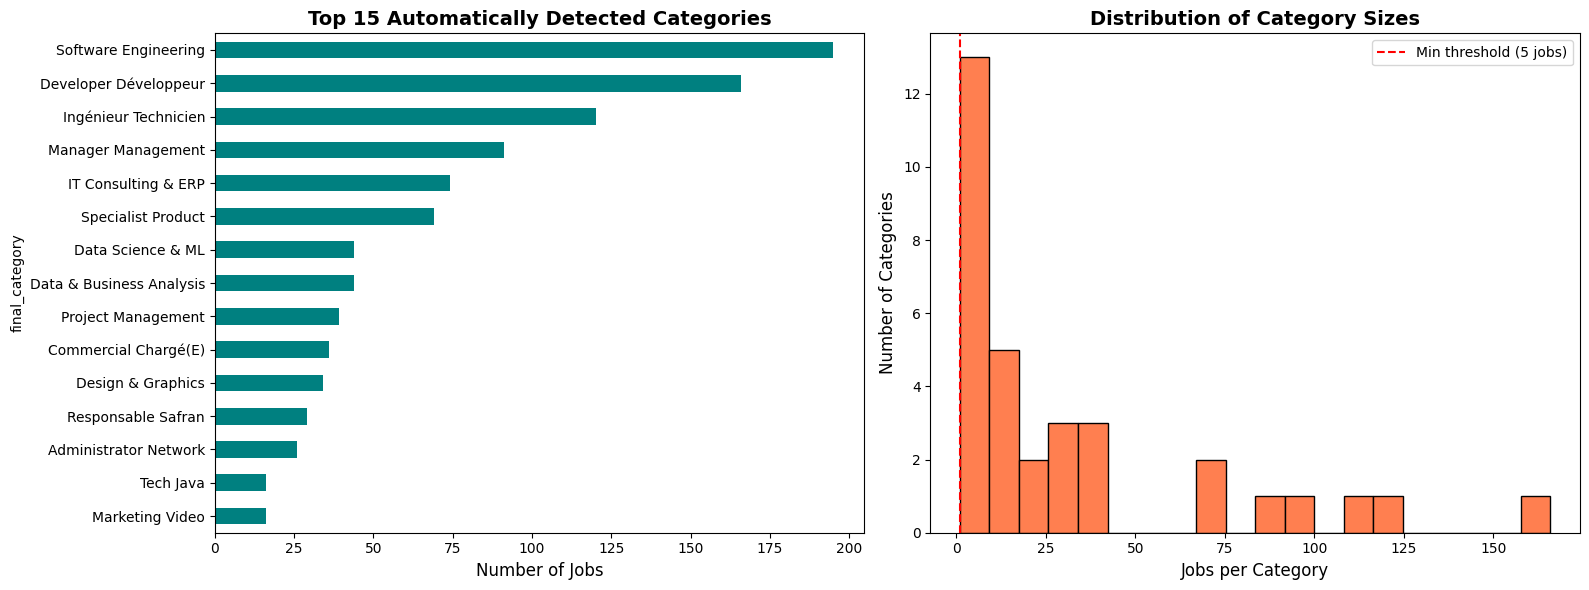

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 categories
top_categories = category_dist.head(15)
top_categories.plot(kind='barh', ax=ax1, color='teal')
ax1.set_xlabel('Number of Jobs', fontsize=12)
ax1.set_title('Top 15 Automatically Detected Categories', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Category sizes distribution
category_sizes = df['final_category'].value_counts().values
ax2.hist(category_sizes, bins=20, color='coral', edgecolor='black')
ax2.set_xlabel('Jobs per Category', fontsize=12)
ax2.set_ylabel('Number of Categories', fontsize=12)
ax2.set_title('Distribution of Category Sizes', fontsize=14, fontweight='bold')
ax2.axvline(1, color='red', linestyle='--', label='Min threshold (5 jobs)')
ax2.legend()

plt.tight_layout()
plt.savefig('auto_clustering_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# See what final_category the data science titles ended up in
data_titles = df[df['title_cleaned'].str.contains(
    'data|scientist|analyst|ml|machine learning|bi|business intel',
    case=False, na=False
)]
print(data_titles[['title_cleaned', 'auto_category', 'final_category']].to_string())

                                                                                       title_cleaned          auto_category                  final_category
0                                                                                 bi / data engineer      Engineer Software               Data Science & ML
1                                                                                      data engineer      Engineer Software               Data Science & ML
2                                                                                      data engineer      Engineer Software               Data Science & ML
3                                                                                      data engineer      Engineer Software               Data Science & ML
4                                                                                       data analyst       Analyst Business        Data & Business Analysis
8                                                               

In [ ]:
def fix_data_categories(row):
    title = str(row['title_cleaned']).lower()
    current = row['final_category']

    # ── Cybersecurity ── (check first, before analyst catch-all)
    if any(k in title for k in ['cybersecurity', 'cyber security', 'cyber',
                                  'soc analyst', 'secops', 'security analyst',
                                  'information security', 'pentest', 'siem']):
        return 'Cybersecurity'

    # ── Data Science & ML ──
    if any(k in title for k in ['data scientist', 'ml engineer', 'mlops', 'nlp',
                                  'machine learning', 'statistician', 'big data']):
        return 'Data Science & ML'

    # ── BI & Data Analysis ──
    if any(k in title for k in ['bi ', 'business intelligence', 'bi/', '/bi',
                                  'data analyst', 'analyste de données',
                                  'analyste bi', 'data lead', 'data architect',
                                  'revenue management analyst']):
        return 'BI & Data Analysis'

    # ── Data Engineering ──
    if any(k in title for k in ['data engineer', 'ingénieur data', 'ingenieur data',
                                  'data governance', 'dataops']):
        return 'Data Science & ML'

    return current

df['final_category'] = df.apply(fix_data_categories, axis=1)
print(df['final_category'].value_counts())

final_category
Developer Développeur              166
Software Engineering               122
Ingénieur Technicien               110
Data Science & ML                   96
Manager Management                  84
IT Consulting & ERP                 72
Specialist Product                  69
Project Management                  39
Commercial Chargé(E)                36
Design & Graphics                   34
BI & Data Analysis                  30
Administrator Network               26
Cybersecurity                       26
Responsable Safran                  25
Data & Business Analysis            19
DevOps Engineering                  17
Tech Java                           15
Buyer Project                       15
Special Projects & Internships      14
Marketing Video                     14
Opérateur Télévendeur(Se)            9
Recruitment                          8
Expert Web                           5
Other                                5
Enterprise Software Development      3
Operations

In [ ]:
valid_categories = category_dist[category_dist >= 5].index.tolist()

print(f"\n{'='*70}")
print(f"CATEGORIES WITH 5+ JOBS (good for skill extraction)")
print(f"{'='*70}")
print(f"Total: {len(valid_categories)} categories")
print(f"\n{category_dist[category_dist >= 5]}")



CATEGORIES WITH 5+ JOBS (good for skill extraction)
Total: 21 categories

final_category
Software Engineering              195
Developer Développeur             166
Ingénieur Technicien              120
Manager Management                 91
IT Consulting & ERP                74
Specialist Product                 69
Data Science & ML                  44
Data & Business Analysis           44
Project Management                 39
Commercial Chargé(E)               36
Design & Graphics                  34
Responsable Safran                 29
Administrator Network              26
Tech Java                          16
Marketing Video                    16
Special Projects & Internships     15
Buyer Project                      15
Opérateur Télévendeur(Se)           9
Recruitment                         8
Expert Web                          5
Other                               5
Name: count, dtype: int64


In [ ]:
mapping_df = pd.DataFrame([
    {
        'cluster_id': cid,
        'category_name': cluster_names[cid],
        'num_titles': len(cluster_titles[cid]),
        'sample_titles': ' | '.join(cluster_titles[cid][:3])
    }
    for cid in sorted(cluster_names.keys())
])

mapping_df.to_csv('cluster_mapping.csv', index=False)
print(f"\n✓ Saved cluster mapping to 'cluster_mapping.csv'")

# Save enhanced dataframe
df.to_csv('linkedin_jobs_with_auto_categories.csv', index=False)
print(f"✓ Saved dataset with auto categories to 'linkedin_jobs_with_auto_categories.csv'")



In [ ]:
print(df[df['final_category'] == 'Software Engineering'][['title_cleaned', 'auto_category']].to_string())

                                                                                       title_cleaned      auto_category
6                                                                                  software engineer  Engineer Software
7                                                          embedded system engineer in sfax, tunisia  Engineer Software
15                                                                        pricing analytics engineer  Engineer Software
17                                                                            software engineer .net  Engineer Software
18                                                                        embedded software engineer  Engineer Software
21                                                                                 founding engineer  Engineer Software
27                                                                          senior software engineer  Engineer Software
28                                      